# Imports

In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/playground-series-s6e3/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e3/train.csv
/kaggle/input/competitions/playground-series-s6e3/test.csv


In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import math

from sklearn.feature_selection import mutual_info_classif
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import RandomizedSearchCV

# Data Exploration

In [3]:
data = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/train.csv', index_col = 'id')
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
id,,,,,,,,,,,,,,,,,,,,
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [4]:
data.shape[0]

594194

In [5]:
data.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 594194 entries, 0 to 594193
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   gender            594194 non-null  object 
 1   SeniorCitizen     594194 non-null  int64  
 2   Partner           594194 non-null  object 
 3   Dependents        594194 non-null  object 
 4   tenure            594194 non-null  int64  
 5   PhoneService      594194 non-null  object 
 6   MultipleLines     594194 non-null  object 
 7   InternetService   594194 non-null  object 
 8   OnlineSecurity    594194 non-null  object 
 9   OnlineBackup      594194 non-null  object 
 10  DeviceProtection  594194 non-null  object 
 11  TechSupport       594194 non-null  object 
 12  StreamingTV       594194 non-null  object 
 13  StreamingMovies   594194 non-null  object 
 14  Contract          594194 non-null  object 
 15  PaperlessBilling  594194 non-null  object 
 16  PaymentMethod     594194 

In [7]:
categorical_cols = list(data.select_dtypes('object').columns)
numerical_cols = list(data.select_dtypes(['float64', 'int64']).columns)

In [8]:
data['SeniorCitizen'].value_counts()

SeniorCitizen
0    526395
1     67799
Name: count, dtype: int64

In [9]:
categorical_cols.append('SeniorCitizen')

In [10]:
numerical_cols.remove('SeniorCitizen')

In [11]:
def plot_feature_distributions(data, cat_cols=None, num_cols=None, target_col=None, ncols=3):
    
    if num_cols:
        n = len(num_cols)
        nrows = math.ceil(n / ncols)

        fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
        axes = axes.flatten()

        for i, col in enumerate(num_cols):
            if target_col:
                sns.histplot(
                    data=data,
                    x=col,
                    hue=target_col,
                    kde=True,
                    ax=axes[i],
                    element="step",
                    stat="density",
                    common_norm=False
                )
            else:
                sns.histplot(data[col], kde=True, ax=axes[i])

            axes[i].set_title(col)

        for j in range(i+1, len(axes)):
            fig.delaxes(axes[j])

        fig.suptitle("Numerical Features", fontsize=16)
        plt.tight_layout()
        plt.show()
        
    if cat_cols:
        n = len(cat_cols)
        nrows = math.ceil(n / ncols)

        fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
        axes = axes.flatten()

        for i, col in enumerate(cat_cols):
            plot_data = data.copy()
            plot_data[col] = plot_data[col].fillna('Missing')

            if target_col:
                sns.countplot(
                    data=plot_data,
                    x=col,
                    hue=target_col,
                    ax=axes[i]
                )
                axes[i].set_title(col)
                axes[i].tick_params(axis='x', rotation=45)
            else:
                counts = plot_data[col].value_counts()

                if len(counts) > 6:
                    top = counts[:6]
                    other = counts[6:].sum()
                    counts = top.copy()
                    counts['Other'] = other

                axes[i].pie(
                    counts,
                    labels=counts.index,
                    autopct='%1.1f%%',
                    startangle=90
                )
                axes[i].set_title(col)

        for j in range(i+1, len(axes)):
            fig.delaxes(axes[j])

        fig.suptitle("Categorical Features", fontsize=16)
        plt.tight_layout()
        plt.show()

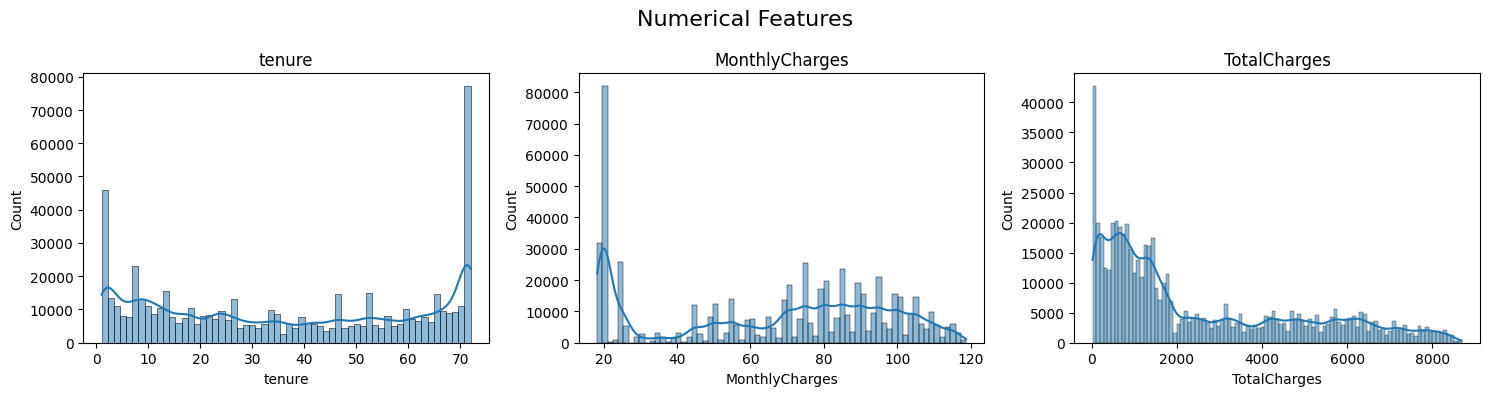

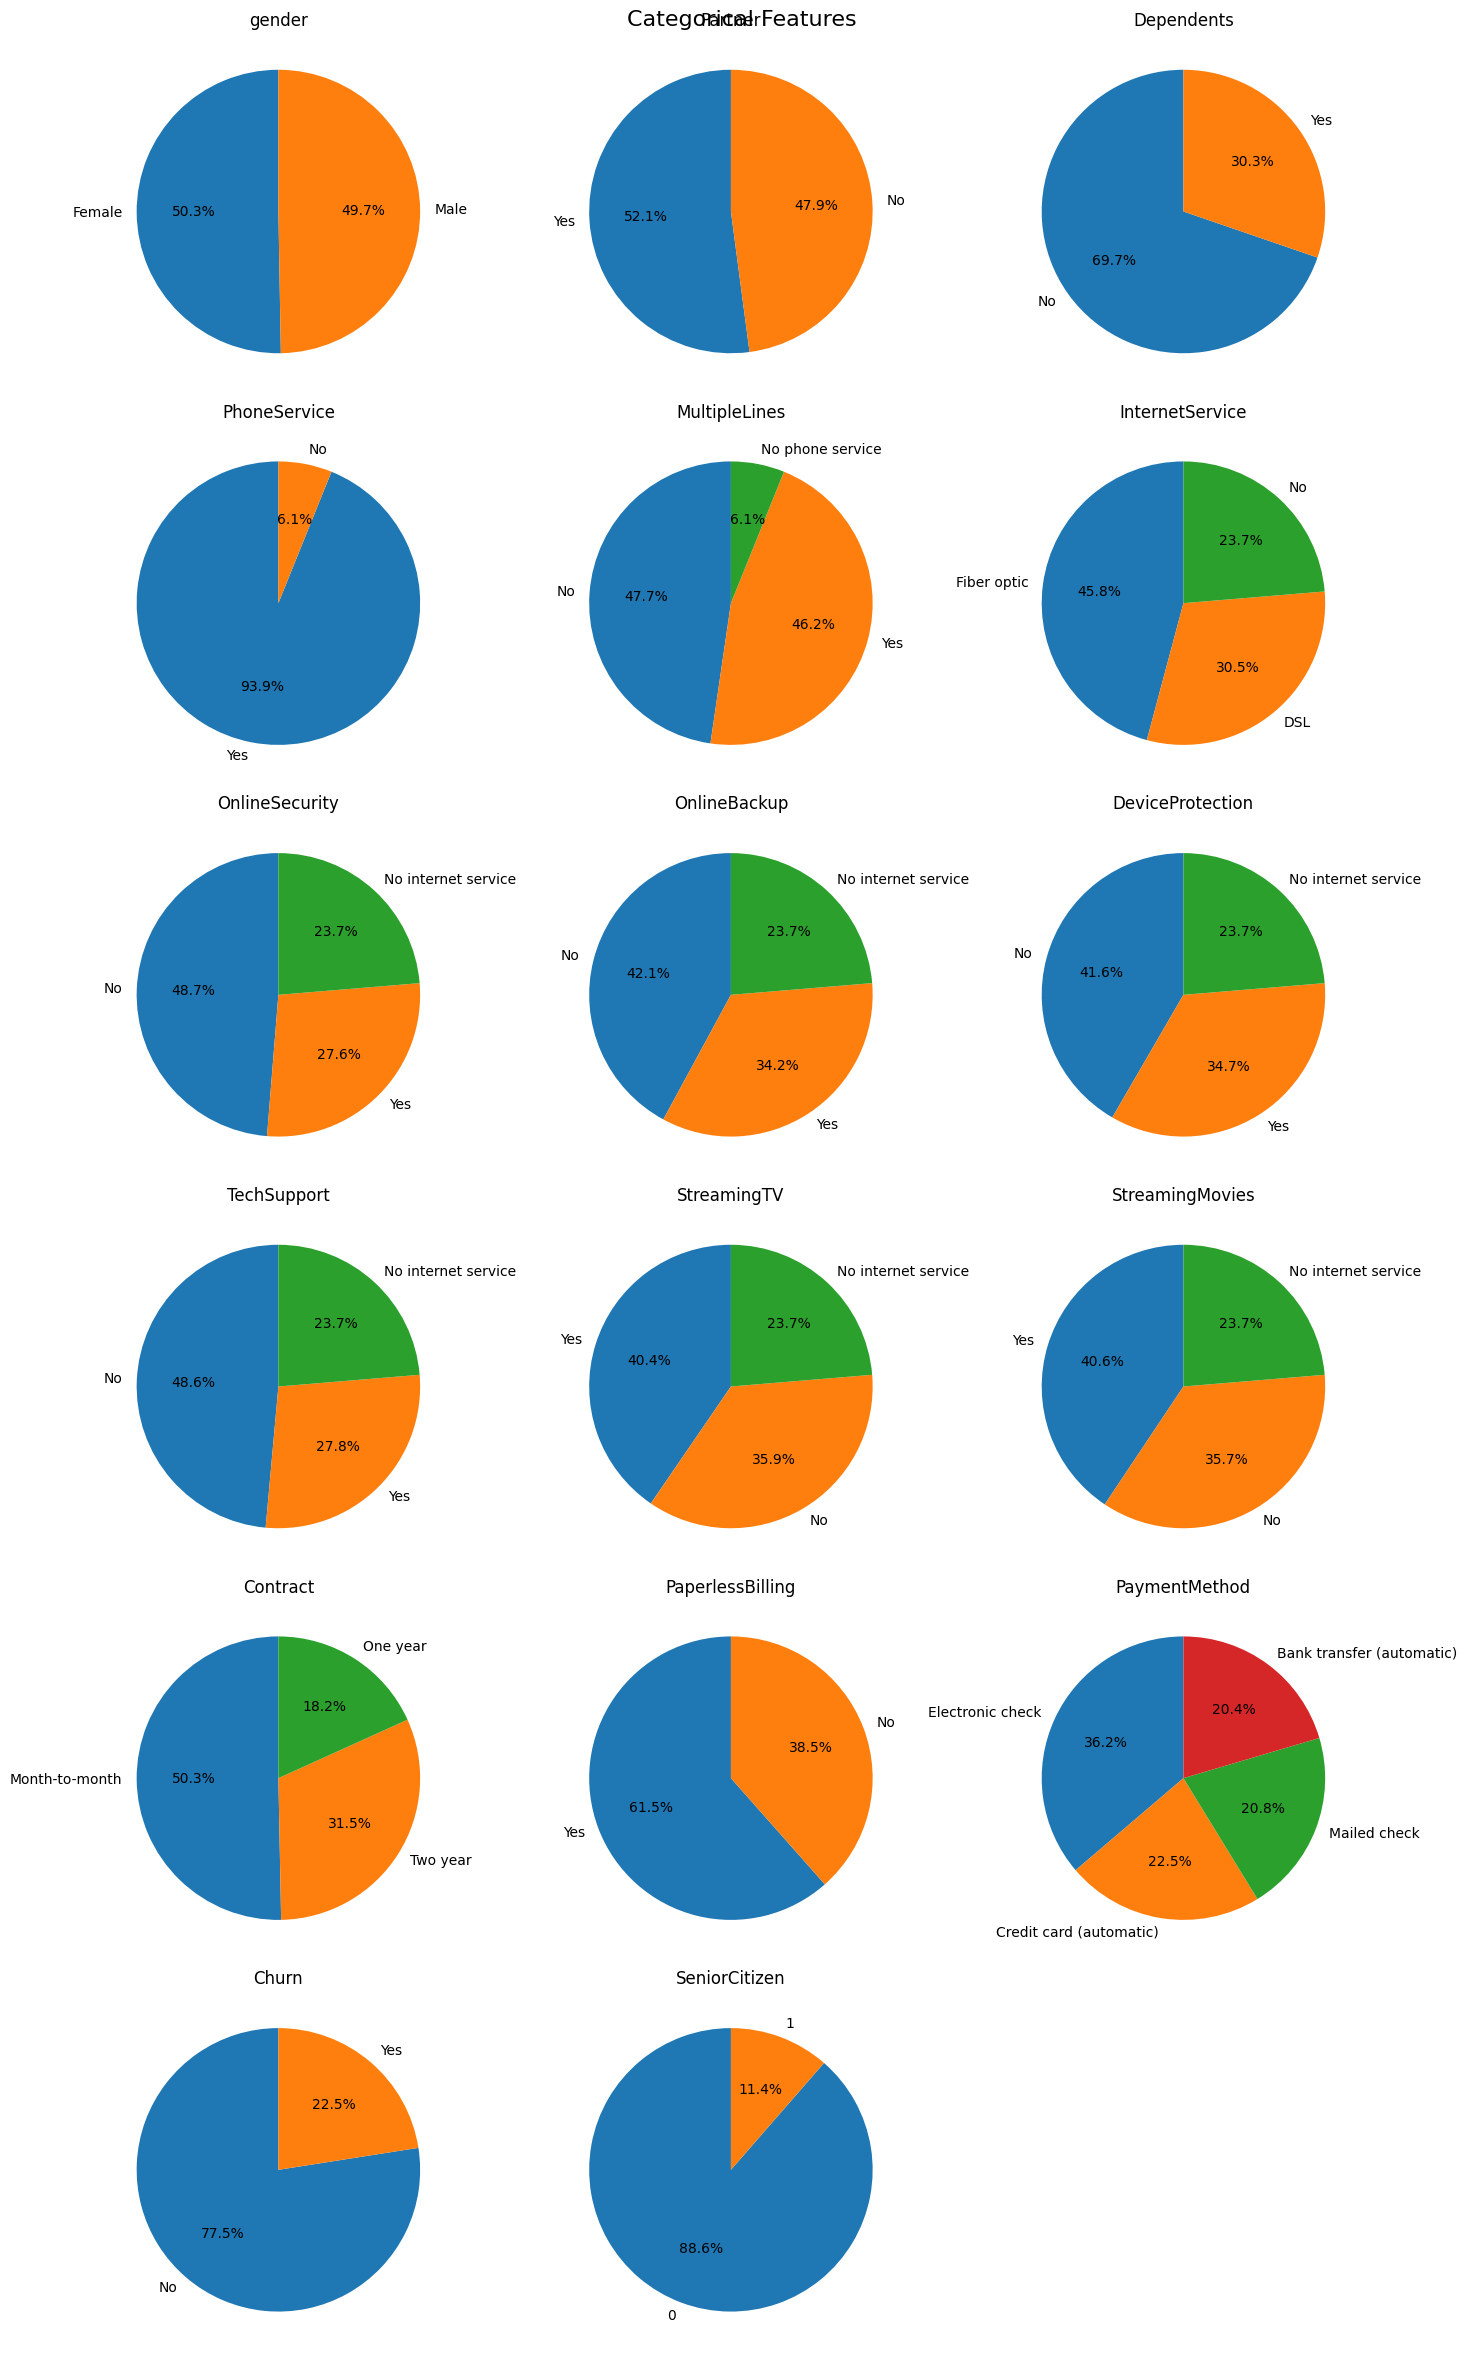

In [12]:
plot_feature_distributions(data, categorical_cols, numerical_cols)

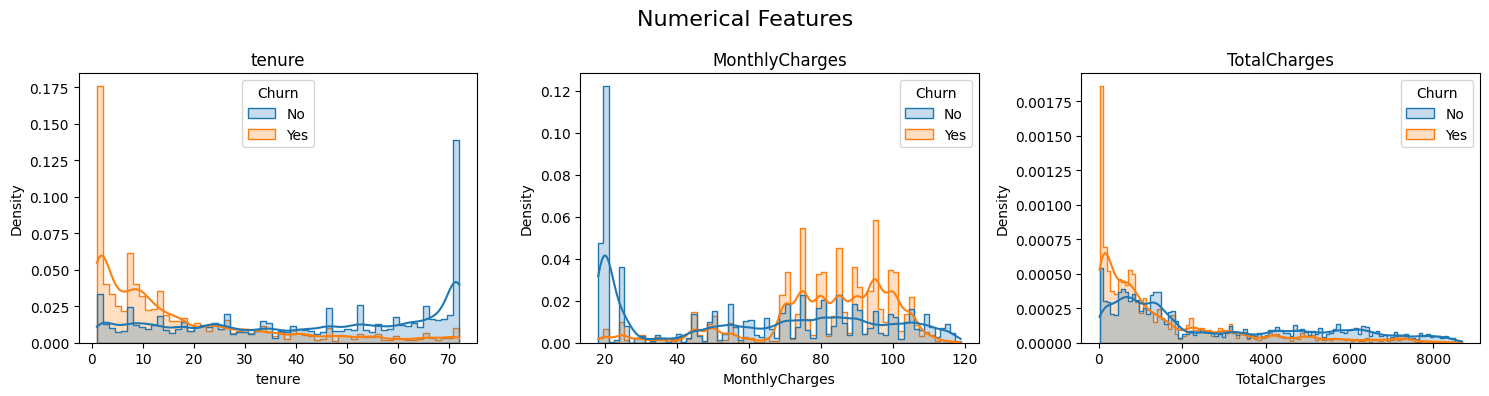

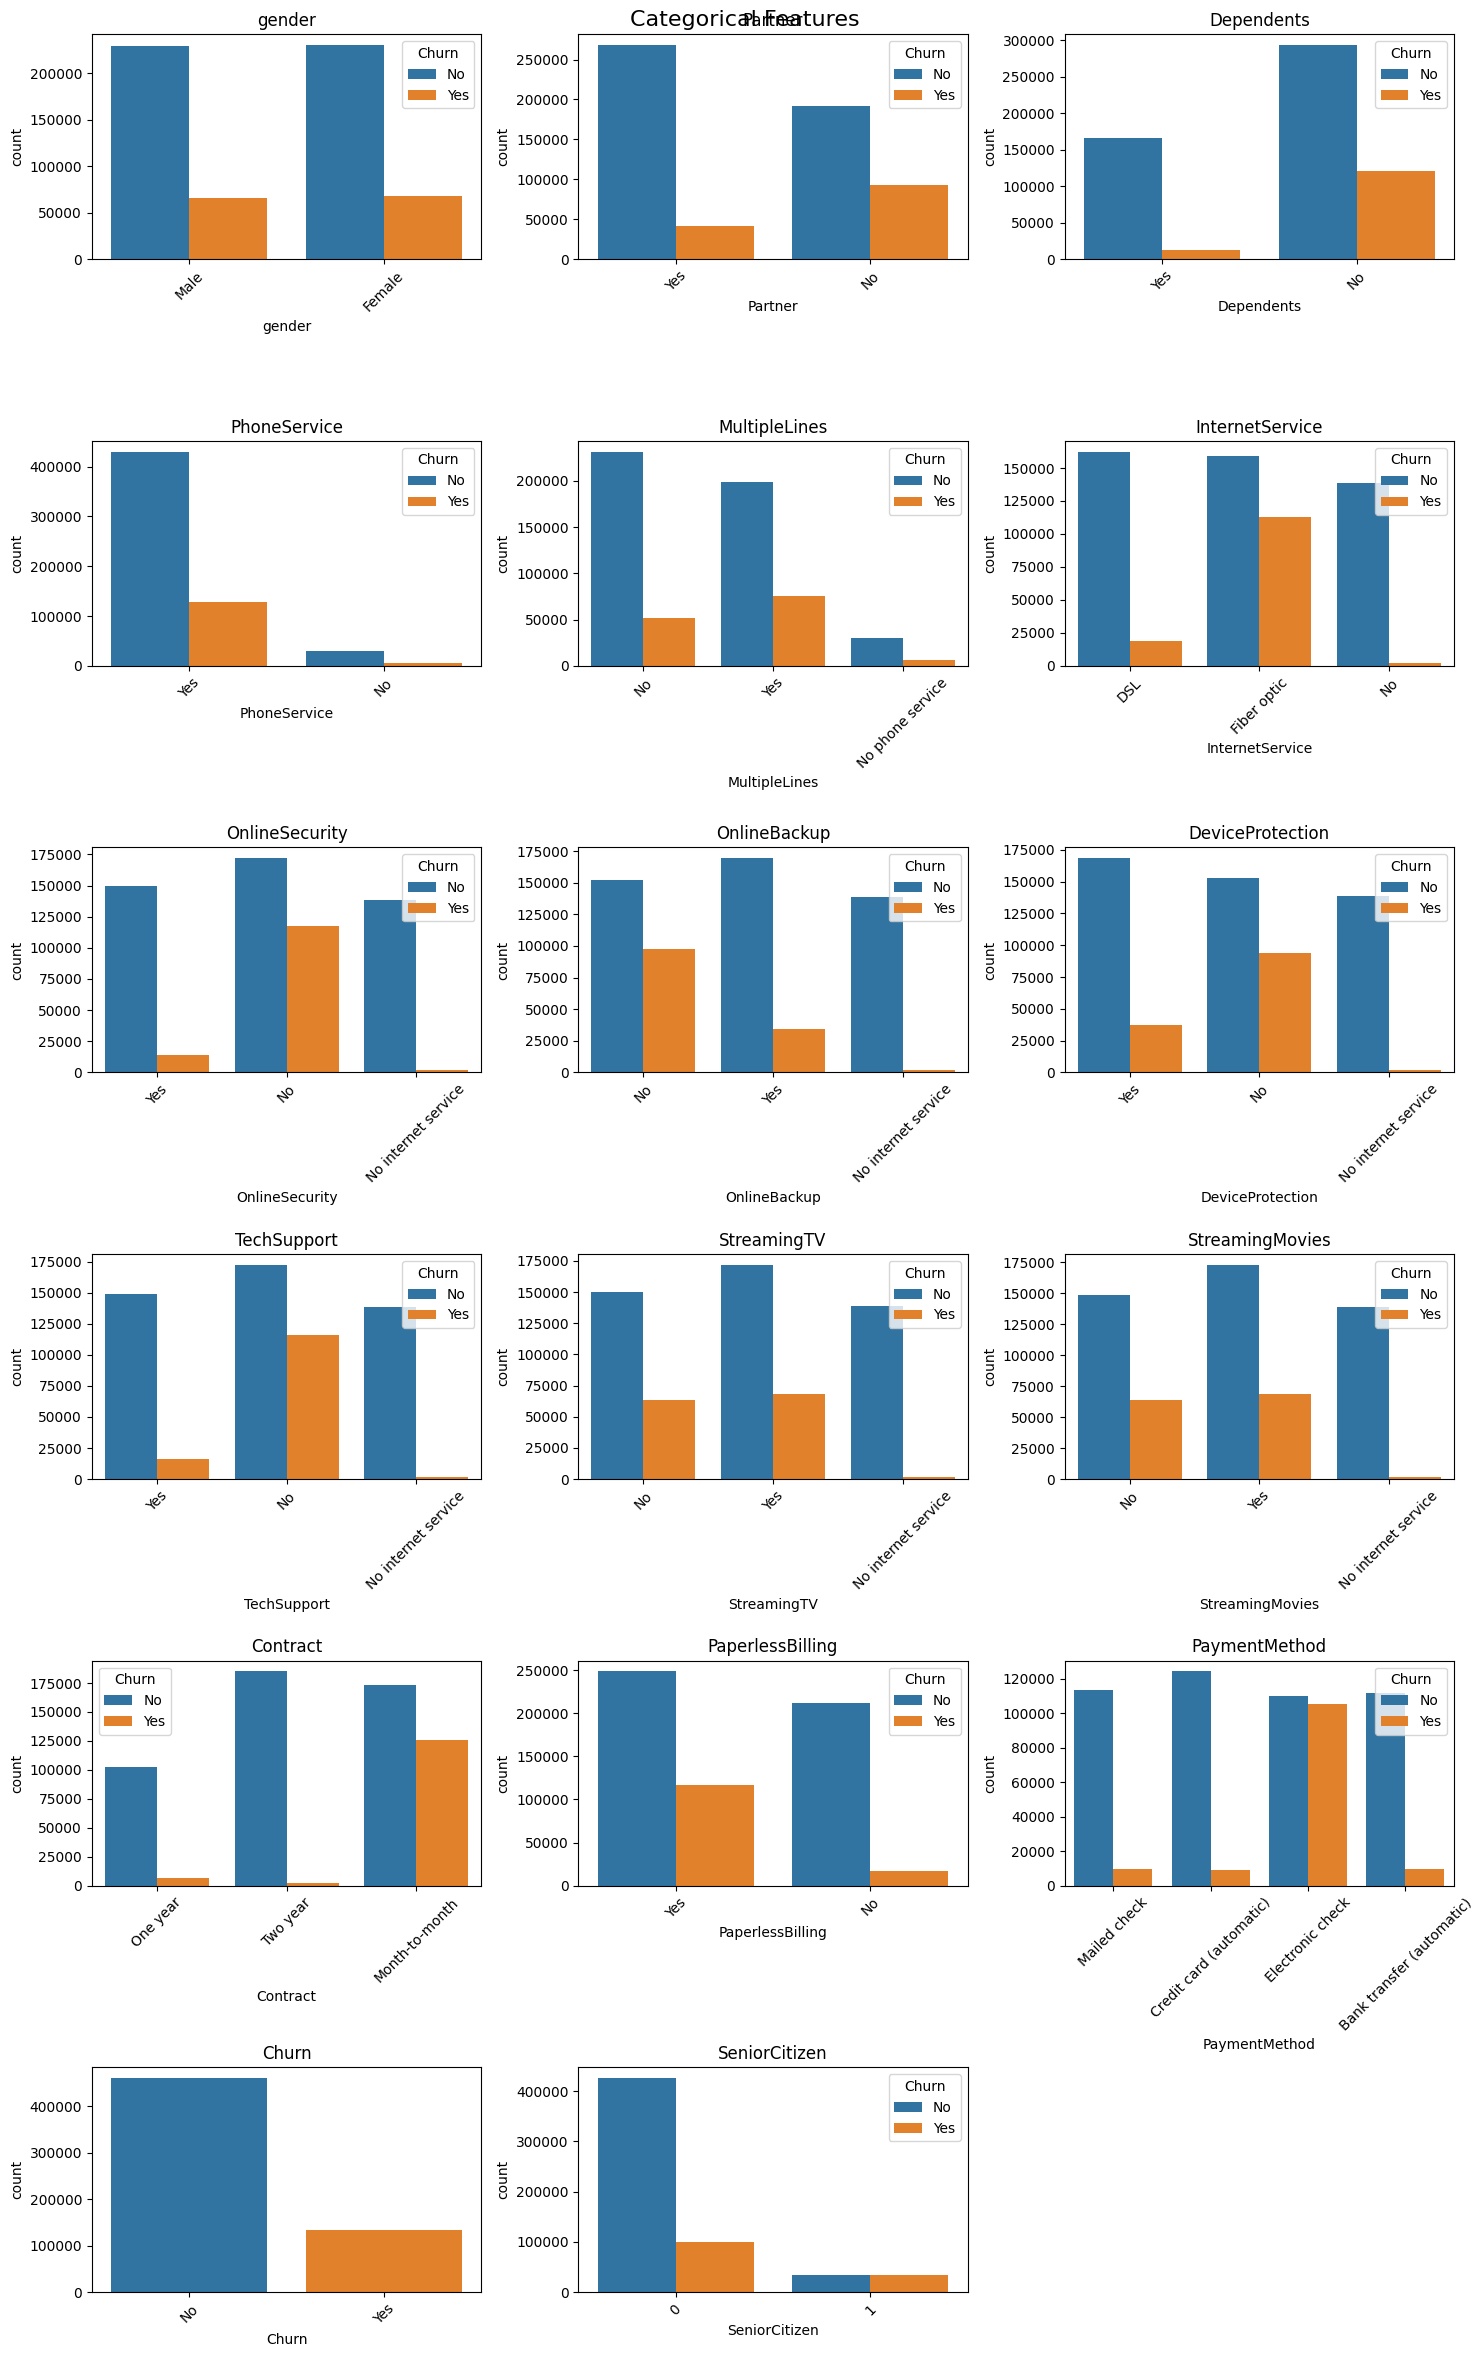

In [13]:
plot_feature_distributions(data, categorical_cols, numerical_cols, 'Churn')

In [14]:
X = data.drop('Churn', axis=1)
y = data['Churn']

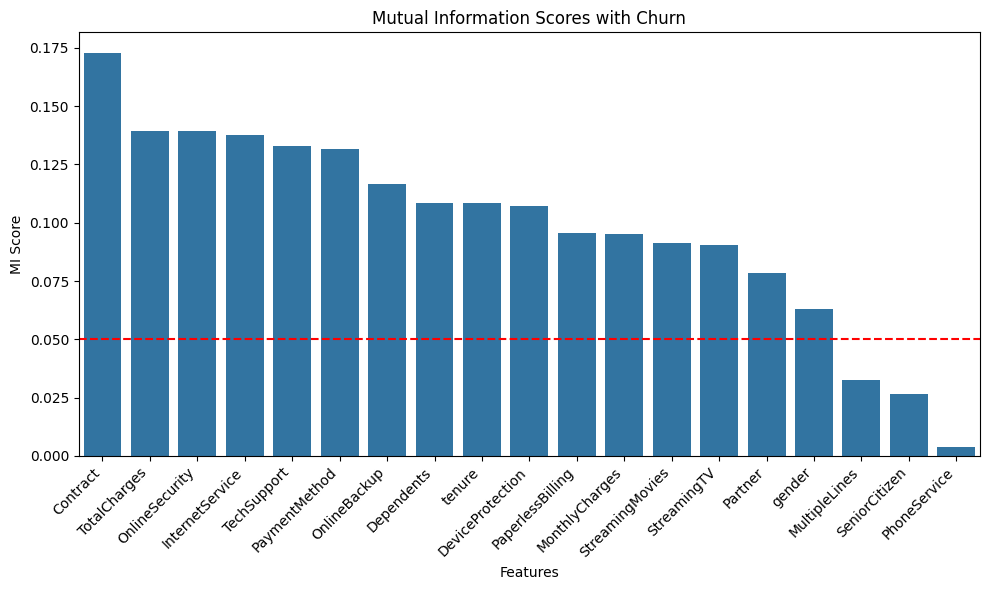

In [15]:
def make_mi_scores(X, y):
    ### Assumes no null values
    X = X.copy()
    # Convert categorical features to integers for mutual_info_classif
    for colname in X.select_dtypes(['object', 'category']):
        X[colname], _ = X[colname].factorize()

    mi_scores = mutual_info_classif(X, y)
    mi_scores = pd.Series(mi_scores, name='MI Scores', index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=0)
    return mi_scores

mi_scores = make_mi_scores(X, y)

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x=mi_scores.index, y=mi_scores.values)
plt.title('Mutual Information Scores with Churn')
plt.xlabel('Features')
plt.ylabel('MI Score')
plt.axhline(y = 0.05, color='r', linestyle = '--')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Preprocessing and Initial Modelling

In [16]:
cat_cols = categorical_features
num_cols = numerical_features

NameError: name 'categorical_features' is not defined

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_cols),
        ('num', 'passthrough', num_cols)
    ]
)

# Full pipeline
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42
    ))
])

In [ ]:
y_encoded = y.str.strip().str.lower().map({'no': 0, 'yes': 1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded 
)

model.fit(X_train, y_train)

In [ ]:
preds = model.predict(X_test)
probs = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, preds))
print("ROC-AUC:", roc_auc_score(y_test, probs))

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    preds,
    display_labels=['No', 'Yes']
)

# Model Tuning

## Feature Analysis

In [ ]:
booster = model.named_steps['classifier']
importances = booster.feature_importances_

feature_names = model.named_steps['preprocessor'].get_feature_names_out()

import pandas as pd
fi = pd.Series(importances, index=feature_names).sort_values(ascending=False)

In [ ]:
fi.head(20).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top Feature Importances")
plt.show()

In [ ]:
import shap

X_sample = X_test.sample(3000, random_state=42)
X_transformed = model.named_steps['preprocessor'].transform(X_sample)

explainer = shap.TreeExplainer(model.named_steps['classifier'])
shap_values = explainer.shap_values(X_transformed)
feature_names = model.named_steps['preprocessor'].get_feature_names_out()

X_transformed_df = pd.DataFrame(X_transformed, columns=feature_names)

shap.summary_plot(shap_values, X_transformed_df)

## Model Evaluation

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

param_dist = {
    'classifier__n_estimators': [300, 500, 800],
    'classifier__max_depth': [4, 6, 8, 10],
    'classifier__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'classifier__subsample': [0.7, 0.8, 1.0],
    'classifier__colsample_bytree': [0.7, 0.8, 1.0],
    'classifier__min_child_weight': [1, 3, 5],
    'classifier__gamma': [0, 0.1, 0.3],
    'classifier__reg_lambda': [1, 5, 10]
}

In [ ]:
random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=20,                 # increase to 50+ if time allows
    scoring='roc_auc',
    cv=3,                    
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

In [ ]:
print("Best params:")
print(random_search.best_params_)

best_model = random_search.best_estimator_

In [ ]:
from sklearn.metrics import roc_auc_score, accuracy_score

preds = best_model.predict(X_test)
probs = best_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, preds))
print("ROC-AUC:", roc_auc_score(y_test, probs))

# Test data

In [ ]:
test_data = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/test.csv', index_col = 'id')

In [ ]:
output = pd.DataFrame(
    best_model.predict(test_data),
    index=test_data.index,
    columns=['prediction']
).replace({'prediction': {1: 'Yes', 0: 'No'}})

In [ ]:
output.value_counts()

In [ ]:
output.to_csv('prediction0.csv', index = False)